In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

In [2]:
df=pd.read_csv('Titanic-Dataset.csv')

In [3]:
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df['has_cabin']=df['Cabin'].notnull().astype(int) #more than 80% values were emplty so its good to drop but may help in some results so keep as had cabin or not => rich or poor

In [6]:
df=df.drop(columns='Cabin')

In [7]:
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,has_cabin
798,799,0,3,"Ibrahim Shawah, Mr. Yousseff",male,30.0,0,0,2685,7.2292,C,0
202,203,0,3,"Johanson, Mr. Jakob Alfred",male,34.0,0,0,3101264,6.4958,S,0
123,124,1,2,"Webber, Miss. Susan",female,32.5,0,0,27267,13.0000,S,1
428,429,0,3,"Flynn, Mr. James",male,NaN,0,0,364851,7.7500,Q,0
448,449,1,3,"Baclini, Miss. Marie Catherine",female,5.0,2,1,2666,19.2583,C,0


In [8]:
df['Fare'].duplicated().sum()


np.int64(643)

In [9]:
df.groupby('Pclass')['Fare'].median()

Pclass
1    60.2875
2    14.2500
3     8.0500
Name: Fare, dtype: float64

In [10]:
df['Fare']=df['Fare'].fillna(df.groupby(['Pclass'])['Fare'].transform('median'))

In [11]:
df.groupby(['Sex','Pclass'])['Age'].median()


Sex     Pclass
female  1         35.0
        2         28.0
        3         21.5
male    1         40.0
        2         30.0
        3         25.0
Name: Age, dtype: float64

In [12]:
df['Age']=df['Age'].fillna(df.groupby(['Sex','Pclass'])['Age'].transform('median'))

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     889 non-null    object 
 11  has_cabin    891 non-null    int64  
dtypes: float64(2), int64(6), object(4)
memory usage: 83.7+ KB


In [14]:
df['Sex']=df['Sex'].map({'male':0,'female':1})

In [15]:
df.sample()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,has_cabin
311,312,1,1,"Ryerson, Miss. Emily Borie",1,18.0,2,2,PC 17608,262.375,C,1


In [16]:
df[df['Embarked'].isnull()]
df.loc[df['Embarked'].isnull(), 'Embarked'] = 'C'

# Pclass = 1
# Fare = ~80
# Which matches Cherbourg (C)
df=pd.get_dummies(df,columns=['Embarked'],drop_first=True,dtype='int')

In [17]:
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,has_cabin,Embarked_Q,Embarked_S
642,643,0,3,"Skoog, Miss. Margit Elizabeth",1,2.0,3,2,347088,27.9000,0,0,1
840,841,0,3,"Alhomaki, Mr. Ilmari Rudolf",0,20.0,0,0,SOTON/O2 3101287,7.9250,0,0,1
748,749,0,1,"Marvin, Mr. Daniel Warner",0,19.0,1,0,113773,53.1000,1,0,1
768,769,0,3,"Moran, Mr. Daniel J",0,25.0,1,0,371110,24.1500,0,1,0
866,867,1,2,"Duran y More, Miss. Asuncion",1,27.0,1,0,SC/PARIS 2149,13.8583,0,0,0


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    int64  
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  has_cabin    891 non-null    int64  
 11  Embarked_Q   891 non-null    int64  
 12  Embarked_S   891 non-null    int64  
dtypes: float64(2), int64(9), object(2)
memory usage: 90.6+ KB


In [19]:
df['Title']=df['Name'].str.extract(' ([A-Za-z]+)\.',expand=False)

In [20]:
df.drop(columns=['Ticket'])

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,has_cabin,Embarked_Q,Embarked_S,Title
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,7.2500,0,0,1,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,71.2833,1,0,0,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,7.9250,0,0,1,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,53.1000,1,0,1,Mrs
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,8.0500,0,0,1,Mr
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",0,27.0,0,0,13.0000,0,0,1,Rev
887,888,1,1,"Graham, Miss. Margaret Edith",1,19.0,0,0,30.0000,1,0,1,Miss
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",1,21.5,1,2,23.4500,0,0,1,Miss
889,890,1,1,"Behr, Mr. Karl Howell",0,26.0,0,0,30.0000,1,0,0,Mr


In [21]:
df['Title'].unique()

array(['Mr', 'Mrs', 'Miss', 'Master', 'Don', 'Rev', 'Dr', 'Mme', 'Ms',
       'Major', 'Lady', 'Sir', 'Mlle', 'Col', 'Capt', 'Countess',
       'Jonkheer'], dtype=object)

In [22]:
df['Title'].value_counts()

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Mlle          2
Major         2
Col           2
Countess      1
Capt          1
Ms            1
Sir           1
Lady          1
Mme           1
Don           1
Jonkheer      1
Name: count, dtype: int64

In [23]:
df['Title']=df['Title'].replace(['Col','Rev','Ms','Dr','Major','Mlle','Countess','Capt','Sir','Lady','Mme','Don','Jonkheer' ],'Rare')

In [24]:
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,has_cabin,Embarked_Q,Embarked_S,Title
323,324,1,2,"Caldwell, Mrs. Albert Francis (Sylvia Mae Harb...",1,22.0,1,1,248738,29.0000,0,0,1,Mrs
855,856,1,3,"Aks, Mrs. Sam (Leah Rosen)",1,18.0,0,1,392091,9.3500,0,0,1,Mrs
837,838,0,3,"Sirota, Mr. Maurice",0,25.0,0,0,392092,8.0500,0,0,1,Mr
207,208,1,3,"Albimona, Mr. Nassef Cassem",0,26.0,0,0,2699,18.7875,0,0,0,Mr
316,317,1,2,"Kantor, Mrs. Sinai (Miriam Sternin)",1,24.0,1,0,244367,26.0000,0,0,1,Mrs


In [25]:
df=pd.get_dummies(df,columns=['Title'],drop_first=True,dtype='int')

In [26]:
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,has_cabin,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
208,209,1,3,"Carr, Miss. Helen ""Ellen""",1,16.0,0,0,367231,7.7500,0,1,0,1,0,0,0
612,613,1,3,"Murphy, Miss. Margaret Jane",1,21.5,1,0,367230,15.5000,0,1,0,1,0,0,0
73,74,0,3,"Chronopoulos, Mr. Apostolos",0,26.0,1,0,2680,14.4542,0,0,0,0,1,0,0
334,335,1,1,"Frauenthal, Mrs. Henry William (Clara Heinshei...",1,35.0,1,0,PC 17611,133.6500,0,0,1,0,0,1,0
112,113,0,3,"Barton, Mr. David John",0,22.0,0,0,324669,8.0500,0,0,1,0,1,0,0


In [27]:
df.drop(columns=['PassengerId','Name','Ticket'], inplace=True)

In [28]:
df.sample(8)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,has_cabin,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
791,0,2,0,16.0,0,0,26.0000,0,0,1,0,1,0,0
852,0,3,1,9.0,1,1,15.2458,0,0,0,1,0,0,0
284,0,1,0,40.0,0,0,26.0000,1,0,1,0,1,0,0
332,0,1,0,38.0,0,1,153.4625,1,0,1,0,1,0,0
264,0,3,1,21.5,0,0,7.7500,0,1,0,1,0,0,0
728,0,2,0,25.0,1,0,26.0000,0,0,1,0,1,0,0
406,0,3,0,51.0,0,0,7.7500,0,0,1,0,1,0,0
738,0,3,0,25.0,0,0,7.8958,0,0,1,0,1,0,0


In [29]:
df=df[['Title_Miss','Title_Mr','Title_Mrs','Title_Rare','Sex','Age','Pclass','SibSp','Parch','Fare','has_cabin','Embarked_Q','Embarked_S','Survived']]

In [30]:
df.sample(4)

,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,Sex,Age,Pclass,SibSp,Parch,Fare,has_cabin,Embarked_Q,Embarked_S,Survived
404,1,0,0,0,1,20.0,3,0,0,8.6625,0,0,1,0
50,0,0,0,0,0,7.0,3,4,1,39.6875,0,0,1,0
36,0,1,0,0,0,25.0,3,0,0,7.2292,0,0,0,1
597,0,1,0,0,0,49.0,3,0,0,0.0000,0,0,1,0


<Axes: xlabel='Sex', ylabel='Survived'>

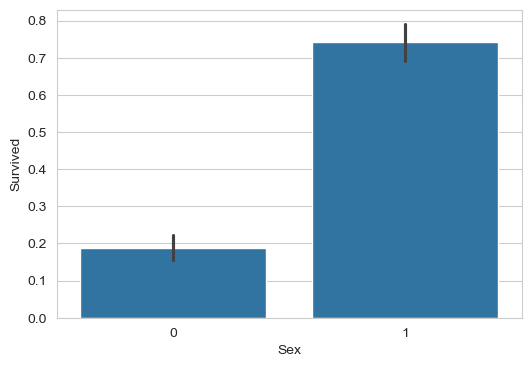

In [31]:
plt.figure(figsize=(6,4))
sns.barplot(x='Sex',y='Survived',data=df)

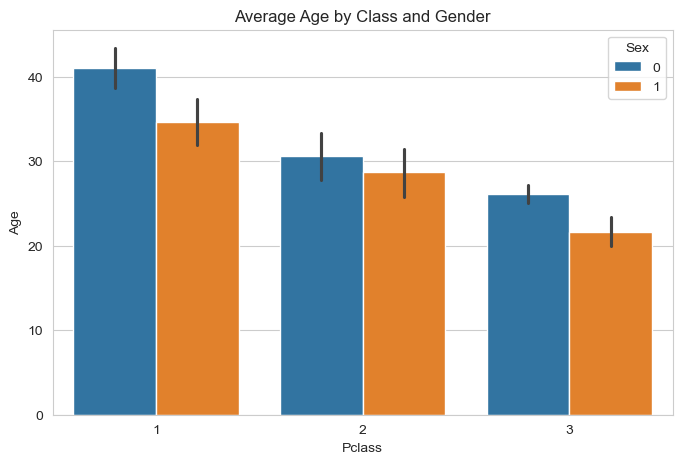

In [32]:
plt.figure(figsize=(8,5))
sns.barplot(x='Pclass', y='Age', hue='Sex', data=df)
plt.title("Average Age by Class and Gender")
plt.show()

In [33]:
df1=df.copy()
bins = [0, 12, 19, 35, 55, 100]
labels = ['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']

df1['AgeGroup'] = pd.cut(df1['Age'], bins=bins, labels=labels)


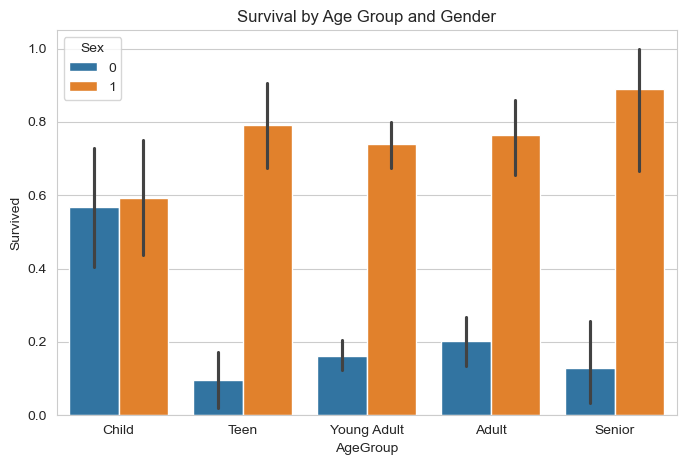

In [34]:
plt.figure(figsize=(8,5))
sns.barplot(x='AgeGroup', y='Survived', hue='Sex', data=df1)
plt.title("Survival by Age Group and Gender")
plt.show()


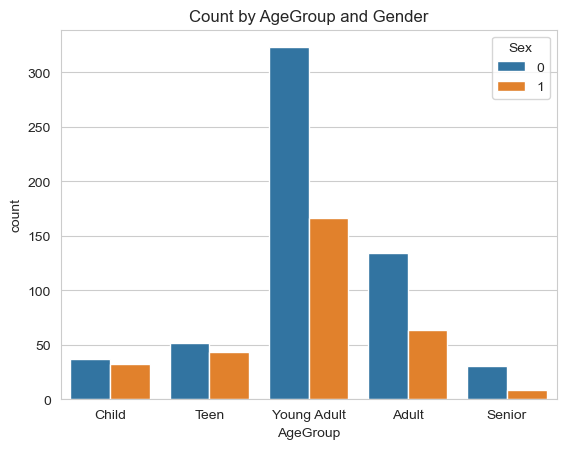

In [35]:
sns.countplot(x='AgeGroup', hue='Sex', data=df1)
plt.title("Count by AgeGroup and Gender")
plt.show()


<Axes: xlabel='AgeGroup', ylabel='Survived'>

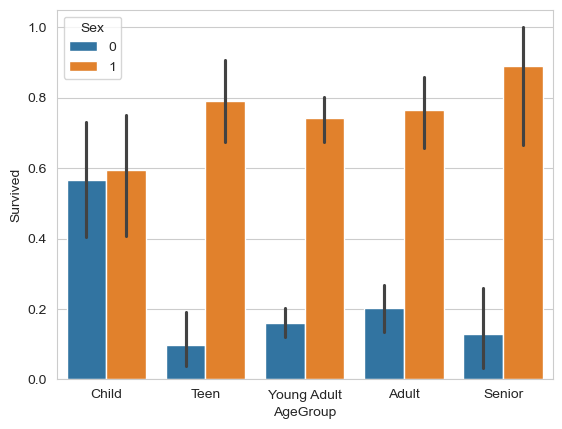

In [36]:
sns.barplot(x='AgeGroup', y='Survived', hue='Sex', data=df1)


C:\Users\Yashika Sharma\AppData\Local\Temp\ipykernel_6660\2888995681.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rates = df1.groupby(['AgeGroup','Sex'])['Survived'].mean().reset_index()


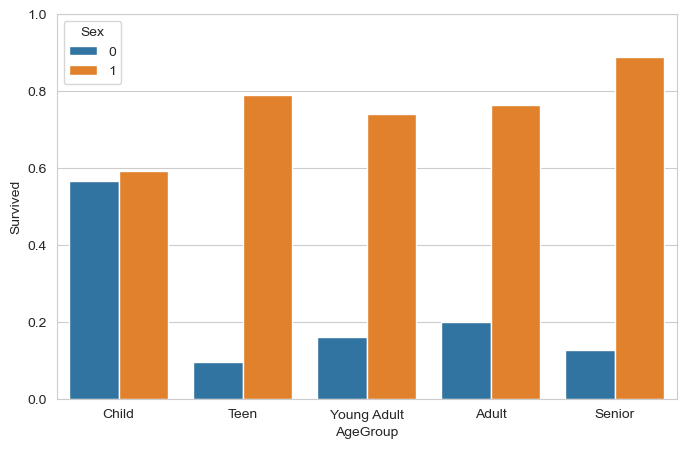

In [37]:
rates = df1.groupby(['AgeGroup','Sex'])['Survived'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(x='AgeGroup', y='Survived', hue='Sex', data=rates)
plt.ylim(0,1)
plt.show()



In [38]:
from sklearn.model_selection import train_test_split

X = df.drop('Survived', axis=1)
y = df['Survived']




In [39]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)   # fit only on train
X_test = scaler.transform(X_test)         # transform test



In [40]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [41]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", model.score(X_test, y_test))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.8379888268156425
[[90 15]
 [14 60]]
              precision    recall  f1-score   support

           0       0.87      0.86      0.86       105
           1       0.80      0.81      0.81        74

    accuracy                           0.84       179
   macro avg       0.83      0.83      0.83       179
weighted avg       0.84      0.84      0.84       179

